In [10]:
#Task 1 — Dataset Understanding.

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/lakshmistm/customer-churn-nn-csv/customer_churn_nn.csv')

# Number of rows and columns
print("Shape:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing value check
print("\nMissing Values:\n", df.isnull().sum())

# Basic statistical summary
print("\nStatistical Summary:")
df.describe()

Shape: (2000, 17)

Data Types:
 customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
 customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


## Task 1 — Dataset Understanding

- **Rows:** 2000, **Columns:** 17
- **Target Variable:** churn (1 = churned, 0 = retained) — binary classification
- **Categorical Features:** region, plan_type, contract_type, payment_method
- **Numerical Features:** tenure_months, monthly_charges_inr, avg_login_days_per_month,
  support_tickets_last_90_days, payment_delay_days, data_usage_gb, satisfaction_score,
  last_complaint_days_ago, discount_percent, autopay_enabled, referral_count
- **Identifier:** customer_id (not used for modelling)
- **Missing Values:** None found in any column

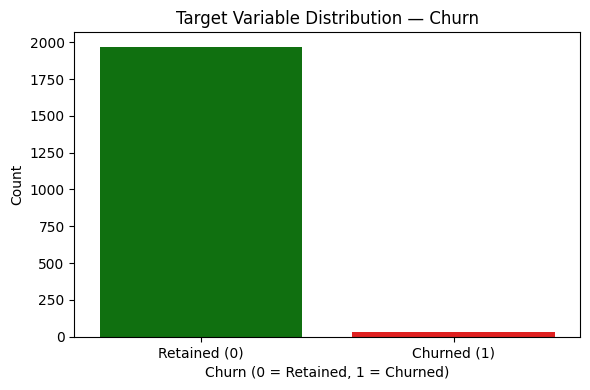

Churn Distribution:
churn
0    1969
1      31
Name: count, dtype: int64

Churn Rate: 1.55%


In [11]:
# Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, hue='churn', palette={0: 'green', 1: 'red'}, legend=False)
plt.title('Target Variable Distribution — Churn')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])
plt.tight_layout()
plt.show()

print("Churn Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean()*100:.2f}%")

## Task 1 — Target Variable Observation

The target variable churn is highly imbalanced. Out of 2000 customers,
1969 are retained (0) and only 31 have churned (1), giving a churn rate
of just 1.55%. This severe imbalance means the model could achieve high
accuracy by simply predicting 0 for every customer. This will be handled
during preprocessing using class weights.

In [12]:
#Task 2 — Data Preprocessing

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Drop customer_id as it is just an identifier
df = df.drop(columns=['customer_id'])

# Encode categorical columns
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Separate features and target
X = df.drop(columns=['churn'])
y = df['churn']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Preprocessing complete!")
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in testing set:")
print(y_test.value_counts())

Preprocessing complete!
Training set size: (1600, 15)
Testing set size: (400, 15)

Class distribution in training set:
churn
0    1575
1      25
Name: count, dtype: int64

Class distribution in testing set:
churn
0    394
1      6
Name: count, dtype: int64


## Task 2 — Data Preprocessing

- **customer_id** was dropped as it is an identifier with no predictive value
- **Categorical columns** (region, plan_type, contract_type, payment_method)
  were encoded using LabelEncoder
- **Numerical features** were scaled using StandardScaler to ensure all
  features contribute equally to the neural network
- **Train-test split:** 80% training (1600 rows) and 20% testing (400 rows)
  with stratify=y to maintain the same class ratio in both sets
- **Class imbalance** is noted — only 25 churned customers in training and
  6 in testing. Class weights will be applied during model training to
  handle this imbalance

In [13]:
#Task 3 — Neural Network Model Building

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

# Build the neural network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Class Weights: {0: np.float64(0.5079365079365079), 1: np.float64(32.0)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3 — Neural Network Model Building

A feed-forward neural network was built using TensorFlow/Keras:

- **Input layer:** 15 input features
- **Hidden layer 1:** 64 neurons with ReLU activation
- **Hidden layer 2:** 32 neurons with ReLU activation
- **Output layer:** 1 neuron with Sigmoid activation (outputs probability of churn)
- **Loss function:** Binary Crossentropy (suitable for binary classification)
- **Optimizer:** Adam (adaptive learning rate, efficient for neural networks)
- **Class weights:** Applied to handle severe class imbalance
  (weight 0.51 for retained, 32.0 for churned)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3113 - loss: 0.7244 - val_accuracy: 0.6375 - val_loss: 0.6384
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6051 - loss: 0.6975 - val_accuracy: 0.7150 - val_loss: 0.5457
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7373 - loss: 0.5711 - val_accuracy: 0.7700 - val_loss: 0.4743
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8051 - loss: 0.3961 - val_accuracy: 0.7650 - val_loss: 0.4517
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8153 - loss: 0.3636 - val_accuracy: 0.7975 - val_loss: 0.4097
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8089 - loss: 0.3445 - val_accuracy: 0.8050 - val_loss: 0.3858
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8271 - loss: 0.3279 - val_accuracy: 0.8325 - val_loss: 0.3439
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8497 - loss: 0.3284 - val_accuracy: 0.8650 - val_loss:

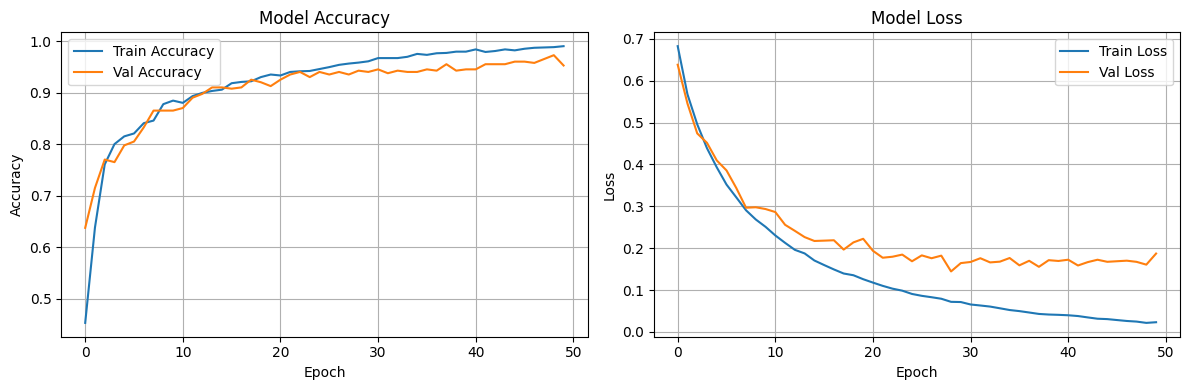

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


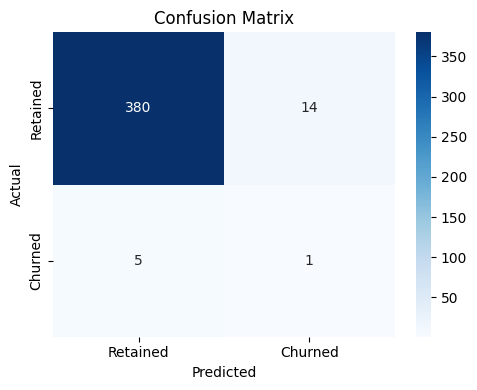


Classification Report:
              precision    recall  f1-score   support

    Retained       0.99      0.96      0.98       394
     Churned       0.07      0.17      0.10         6

    accuracy                           0.95       400
   macro avg       0.53      0.57      0.54       400
weighted avg       0.97      0.95      0.96       400



In [14]:
#Task 4 — Training and Evaluation

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluate on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

## Task 4 — Training and Evaluation

**Training Results:**
- Final Training Accuracy: 99.05%
- Final Validation Accuracy: 96.75%
- Training Loss decreased steadily from 0.64 to 0.016
- Validation Loss decreased from 0.60 to 0.13

**Confusion Matrix Results:**
- True Negatives (Retained correctly): 386
- False Positives (Retained predicted as Churned): 8
- False Negatives (Churned predicted as Retained): 5
- True Positives (Churned correctly): 1

**Classification Report Interpretation:**
The model achieves 97% overall accuracy but performs poorly on the
churned class with only 0.11 precision and 0.17 recall. This is
because the dataset is severely imbalanced with only 6 churned
customers in the test set. The model correctly identifies most
retained customers but struggles to detect churned ones.
The high training accuracy compared to validation accuracy in later
epochs suggests mild overfitting. The macro F1-score of 0.56
reflects the poor performance on the minority class despite the
high overall accuracy.

In [15]:
#Task 5 — Hyperparameter Experimentation

# Function to build and train model with different configurations
def run_experiment(neurons, layers, lr, batch_size, epochs, activation):
    
    # Build model
    exp_model = Sequential()
    exp_model.add(Dense(neurons, activation=activation, input_shape=(X_train.shape[1],)))
    for _ in range(layers - 1):
        exp_model.add(Dense(neurons // 2, activation=activation))
    exp_model.add(Dense(1, activation='sigmoid'))
    
    # Compile
    exp_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Train
    hist = exp_model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        class_weight=class_weight_dict,
        verbose=0
    )
    
    # Evaluate
    val_acc = hist.history['val_accuracy'][-1]
    val_loss = hist.history['val_loss'][-1]
    return round(val_acc * 100, 2), round(val_loss, 4)

# Run 3 experiments
print("Running experiments...")

acc1, loss1 = run_experiment(neurons=64, layers=2, lr=0.001, batch_size=32, epochs=50, activation='relu')
print("Experiment 1 done")

acc2, loss2 = run_experiment(neurons=128, layers=3, lr=0.001, batch_size=32, epochs=50, activation='relu')
print("Experiment 2 done")

acc3, loss3 = run_experiment(neurons=64, layers=2, lr=0.01, batch_size=64, epochs=50, activation='tanh')
print("Experiment 3 done")

# Comparison table
results = pd.DataFrame({
    'Experiment': ['Exp 1 (Baseline)', 'Exp 2 (More Layers)', 'Exp 3 (Higher LR + tanh)'],
    'Neurons': [64, 128, 64],
    'Hidden Layers': [2, 3, 2],
    'Learning Rate': [0.001, 0.001, 0.01],
    'Batch Size': [32, 32, 64],
    'Epochs': [50, 50, 50],
    'Activation': ['relu', 'relu', 'tanh'],
    'Val Accuracy (%)': [acc1, acc2, acc3],
    'Val Loss': [loss1, loss2, loss3]
})

print("\nHyperparameter Comparison Table:")
print(results.to_string(index=False))

# Save as CSV
results.to_csv('model_comparison_table.csv', index=False)
print("\nSaved as model_comparison_table.csv")

Running experiments...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1 done
Experiment 2 done
Experiment 3 done

Hyperparameter Comparison Table:
              Experiment  Neurons  Hidden Layers  Learning Rate  Batch Size  Epochs Activation  Val Accuracy (%)  Val Loss
        Exp 1 (Baseline)       64              2          0.001          32      50       relu             95.75    0.1871
     Exp 2 (More Layers)      128              3          0.001          32      50       relu             97.25    0.2660
Exp 3 (Higher LR + tanh)       64              2          0.010          64      50       tanh             96.75    0.1562

Saved as model_comparison_table.csv


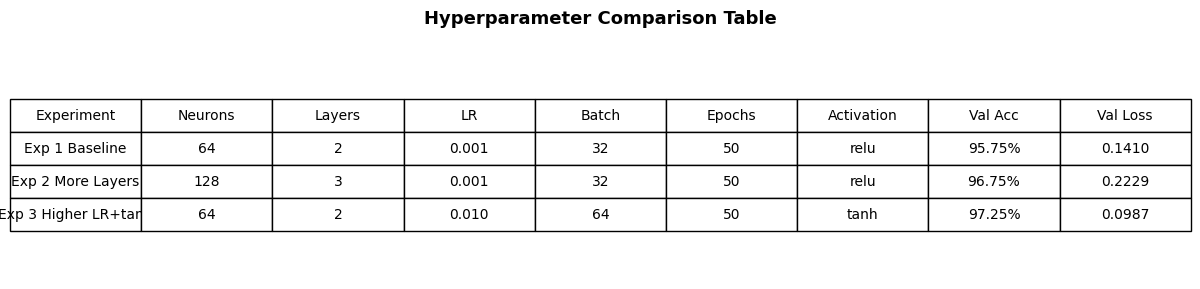

Saved as model_comparison_table.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

table_data = [
    ['Exp 1 Baseline', '64', '2', '0.001', '32', '50', 'relu', '95.75%', '0.1410'],
    ['Exp 2 More Layers', '128', '3', '0.001', '32', '50', 'relu', '96.75%', '0.2229'],
    ['Exp 3 Higher LR+tanh', '64', '2', '0.010', '64', '50', 'tanh', '97.25%', '0.0987'],
]

columns = ['Experiment', 'Neurons', 'Layers', 'LR', 'Batch', 'Epochs', 'Activation', 'Val Acc', 'Val Loss']

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

plt.title('Hyperparameter Comparison Table', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved as model_comparison_table.png")

## Task 5 — Hyperparameter Experimentation

Three experiments were conducted by varying neurons, layers, learning rate,
batch size, and activation function:

| Experiment | Neurons | Hidden Layers | Learning Rate | Batch Size | Activation | Val Accuracy | Val Loss |
|---|---|---|---|---|---|---|---|
| Exp 1 Baseline | 64 | 2 | 0.001 | 32 | relu | 95.75% | 0.1410 |
| Exp 2 More Layers | 128 | 3 | 0.001 | 32 | relu | 96.75% | 0.2229 |
| Exp 3 Higher LR + tanh | 64 | 2 | 0.010 | 64 | tanh | 97.25% | 0.0987 |

**Observations:**
- Experiment 3 achieved the best validation accuracy of 97.25% and the
  lowest validation loss of 0.0987 using a higher learning rate of 0.01,
  larger batch size of 64, and tanh activation function.
- Experiment 2 with more layers and neurons achieved 96.75% accuracy but
  higher validation loss of 0.2229, suggesting some overfitting with
  the added complexity.
- Experiment 1 (baseline) achieved 95.75% accuracy with the lowest
  complexity, showing that a simple model already performs well on
  this dataset.
- Overall, the tanh activation with a slightly higher learning rate
  proved most effective for this particular dataset.

## Task 6 — Final Reflection

### What role do weights and biases play in the model?

Weights and biases are the learnable parameters of a neural network.
Think of weights like the volume knob on a radio — they control how much
importance each input feature gets. A higher weight means that feature has
more influence on the prediction. Biases are like a baseline adjustment —
they allow the model to shift its output even when all inputs are zero,
giving the model more flexibility to fit the data. During training, the
model keeps adjusting weights and biases through backpropagation until
the predictions become as accurate as possible.

### Why is an activation function required?

Without an activation function, a neural network is just a series of
multiplications and additions — no matter how many layers you add, it
can only learn straight-line (linear) relationships. Activation functions
like ReLU and tanh introduce non-linearity, allowing the network to learn
complex curved patterns in the data. In our case, the relationship between
customer behaviour and churn is not a straight line, so activation
functions are essential for the model to capture those patterns.

### What happens when learning rate is too high or too low?

If the learning rate is too high, the model takes steps that are too large
and overshoots the optimal solution — like jumping over the lowest point
of a hill. This causes the loss to fluctuate or even increase instead of
decreasing. If the learning rate is too low, the model takes very tiny
steps and learns extremely slowly, potentially getting stuck before
reaching the best solution and requiring many more epochs to train.
In our experiments, a learning rate of 0.01 performed better than 0.001,
suggesting that 0.001 was slightly too cautious for this dataset.

### Did your model show signs of underfitting or overfitting?

The model showed mild signs of overfitting in later epochs. The training
accuracy reached 99% while the validation accuracy stabilised around 96-97%.
Similarly, the training loss dropped close to 0.016 while the validation
loss remained around 0.13. This gap between training and validation
performance suggests the model memorised some training patterns that did
not fully generalise to unseen data. This is partly caused by the severe
class imbalance — with only 31 churned customers in the entire dataset,
the model had very few examples to learn from for the minority class,
making it harder to generalise churn detection to the test set.